# Notebook 5: The Wall
## Collatz Conjecture - Beautiful Dead Ends

---

### What four notebooks of exploration adds up to

I started this series not to solve the Collatz Conjecture - I was clear about that in Notebook 1 - but to understand why it resists solution. Four notebooks in, I think I have something worth saying about that.

This is the capstone. I'm going to collect the threads from the previous notebooks, characterise the walls I've encountered, and try to say something precise about the *nature* of the difficulty. Not just "it's hard" but *why* it's hard and what kind of hardness it is.

---

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
NEUTRAL = '#888888'
WHITE   = '#dddddd'

# Core functions - reproduced here so this notebook stands alone
def collatz_sequence(n):
    seq = [n]
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        seq.append(n)
    return seq

def stopping_time(n):
    count = 0
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        count += 1
    return count

print('Setup complete.')

Setup complete.


## 1. What I found

Let me be honest about the inventory before I interpret it.

**From Notebook 1** - the problem stated, the sequences visualised. The immediate observation: complete chaos at the individual level, but something ordered in the aggregate. The trajectories look random. The stopping time distribution doesn't.

**From Notebook 2** - stopping times and the tree structure. The Collatz sequences form a binary tree rooted at 1. Every integer appears exactly once in this tree. The tree has the strange property that it's theoretically infinite in every direction, but computation has never found a branch that escapes to infinity or cycles back to itself (other than the known 1→4→2→1 cycle). The tree *looks* like it covers all positive integers. We cannot prove it does.

**From Notebook 3** - published results and the density/universality distinction. Terras (1976) showed that *almost all* integers eventually reach a value smaller than themselves under iteration. This is a density result: the set of integers that don't has density zero. But density zero is not empty. The conjecture requires universality - *every* integer reaches 1. Density-zero exceptions are still infinitely many. The gap between "almost all" and "all" is where the conjecture lives, and it's not a small gap mathematically.

**From Notebook 4** - computational structure of delay records and visit frequencies. Delay records (numbers that take longer to converge than any smaller number) grow in stopping time roughly as a power law. The binary structure of record-holders shows no systematic pattern distinguishing them from ordinary numbers. Visit frequency follows a clear hierarchy - powers of 2 dominate because they're the inevitable bottleneck - but beyond that the distribution is consistent with pseudo-randomness.

The thread running through all of this: **the aggregate is structured, the individual is not.**

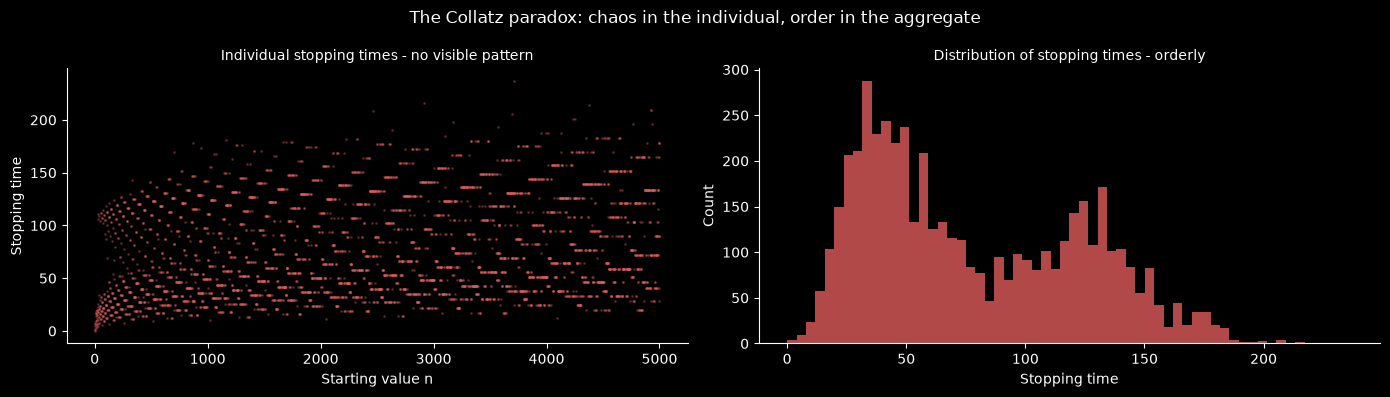

In [7]:
# Visualise the aggregate vs individual contrast
# Stopping times up to N=5000: the distribution is smooth, individual values are not
N = 5000
stopping_times = [stopping_time(n) for n in range(1, N+1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Individual: chaotic
ax = axes[0]
ax.scatter(range(1, N+1), stopping_times, s=1, alpha=0.3, color=ACCENT)
ax.set_xlabel('Starting value n', fontsize=10)
ax.set_ylabel('Stopping time', fontsize=10)
ax.set_title('Individual stopping times - no visible pattern', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Aggregate: smooth
ax = axes[1]
ax.hist(stopping_times, bins=60, color=ACCENT, alpha=0.8, edgecolor='none')
ax.set_xlabel('Stopping time', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('Distribution of stopping times - orderly', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('The Collatz paradox: chaos in the individual, order in the aggregate',
             fontsize=12)
plt.tight_layout()
plt.show()

## 2. The three walls

I've been thinking about the barriers to proof as distinct walls rather than a single obstacle. They're related but they're not the same thing.

### Wall 1: The density-universality gap

This is the clearest wall and the most mathematically precise. We have density results - powerful ones, due to Terras and later Korec - that say the conjecture is true for almost all integers. But proof of the full conjecture requires *universality*: true for every integer without exception.

The density results use measure theory and ergodic arguments. They work beautifully in the aggregate. But measure theory is blind to individual exceptional cases. A set of measure zero can still be infinite. And it's exactly the potential infinite exceptional set that the conjecture is about.

The tools that work for almost-all proofs are structurally unsuited to all-proofs. We'd need to either show the exceptional set is genuinely empty (rather than measure-zero), or develop new tools that can see individual integers rather than typical ones.

### Wall 2: Computational irreducibility

In Notebook 4 I came to the conclusion that Collatz sequences behave, in a precise sense, like pseudo-random processes. The value of $T(n)$ - the stopping time of $n$ - appears unpredictable from any simple property of $n$. Not unpredictable in principle, but unpredictable without running the sequence.

This is what Stephen Wolfram calls *computational irreducibility*: for some systems, the only way to know the output is to run the computation. There's no shortcut.

If Collatz is computationally irreducible in this sense, then any proof of the conjecture cannot proceed by reasoning about individual starting values - it would need to reason about the *class* of all starting values simultaneously. That's a fundamentally different kind of argument.

The existing density proofs do this: they reason about all integers at once using probabilistic and ergodic machinery. But they can't close the gap to universality for exactly this reason - to handle exceptional cases you need to know something about the individual, and the individual is opaque.

### Wall 3: The arithmetic of 3n+1 and 2

There's something specific about the interaction between multiplication by 3 and division by 2 that makes this problem hard. Let me make that precise.

The odd step takes $n \to 3n+1$. Because $3n+1$ is always even when $n$ is odd, this is always immediately followed by at least one halving. The net effect on the 2-adic valuation of $n$ - roughly, how many times 2 divides it - determines whether sequences converge.

If the 2-adic structure of the sequence were more regular, we could reason about it. But the $+1$ in $3n+1$ disrupts the multiplicative structure in a way that makes the 2-adic analysis intractable. Replace $3n+1$ with $3n$ and the problem collapses immediately - $3n$ is never even, so the halving steps never terminate. The $+1$ is doing enormous structural work, and it's exactly what makes the problem hard.

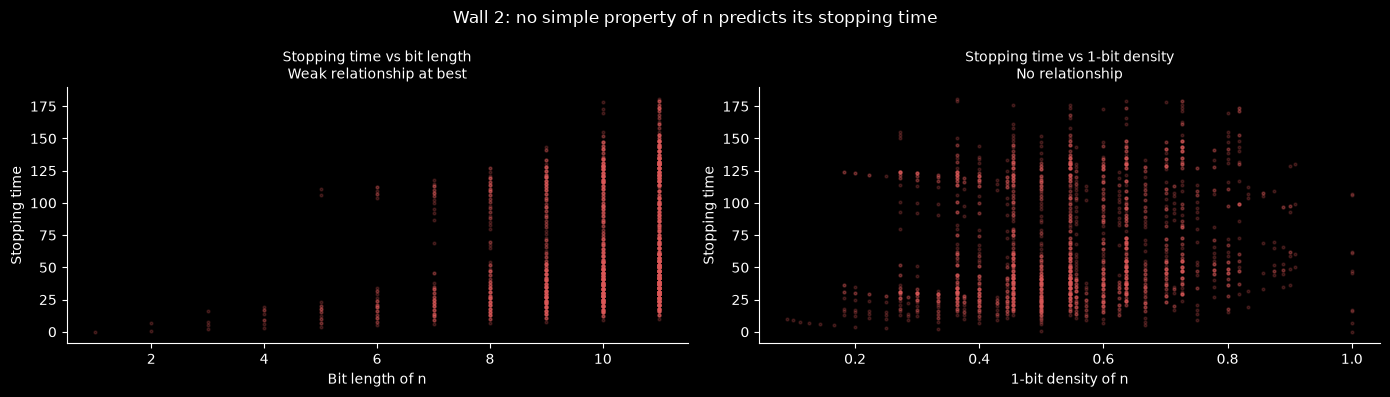

In [8]:
# Illustrate Wall 2: stopping time appears unpredictable from simple properties of n
# If stopping time were related to, say, the number of bits in n,
# we'd see a clear pattern. We don't.

N = 2000
ns = np.arange(1, N+1)
sts = np.array([stopping_time(n) for n in ns])
bit_lengths = np.floor(np.log2(ns)).astype(int) + 1
bit_densities = np.array([bin(n).count('1') / len(bin(n)[2:]) for n in ns])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.scatter(bit_lengths, sts, s=4, alpha=0.2, color=ACCENT)
ax.set_xlabel('Bit length of n', fontsize=10)
ax.set_ylabel('Stopping time', fontsize=10)
ax.set_title('Stopping time vs bit length\nWeak relationship at best', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.scatter(bit_densities, sts, s=4, alpha=0.2, color=ACCENT)
ax.set_xlabel('1-bit density of n', fontsize=10)
ax.set_ylabel('Stopping time', fontsize=10)
ax.set_title('Stopping time vs 1-bit density\nNo relationship', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Wall 2: no simple property of n predicts its stopping time', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Why similar-looking problems are easier

One of the things that makes the Collatz Conjecture feel deceptively approachable is that there are related problems that *are* solved. Understanding why they're easier clarifies what makes Collatz hard.

**The $5n+1$ problem:** Replace $3n+1$ with $5n+1$. This version is false - there are known cycles that don't lead to 1. The proof is easy because the counterexamples are explicit and findable.

**The $3n-1$ problem:** Replace $+1$ with $-1$. This version has multiple known cycles. Again, explicit counterexamples are findable computationally and the proof of their existence is routine.

**The $2n+1$ problem (trivial):** Every odd number maps to an even one, which immediately halves. All sequences converge obviously.

The pattern: when the problem is false, it's easy to prove (find a cycle or diverging sequence). When it's trivially true, it's easy to prove (convergence is obvious). Collatz sits in an uncomfortable middle: it appears to be true, but not obviously so, and not falsely so. That's the hardest possible position for a conjecture to be in.

In [9]:
# Demonstrate that 5n+1 fails - show a cycle
def collatz_variant(n, multiplier=3, constant=1, max_iter=1000):
    seq = [n]
    seen = {n}
    for _ in range(max_iter):
        if n % 2 == 0:
            n = n // 2
        else:
            n = multiplier * n + constant
        if n in seen:
            return seq, True   # cycle detected
        if n == 1:
            return seq, False  # reached 1
        seen.add(n)
        seq.append(n)
    return seq, None  # inconclusive

print('5n+1 problem - looking for cycles:')
for start in [3, 5, 7, 13, 17, 19]:
    seq, cycled = collatz_variant(start, multiplier=5, constant=1)
    status = 'CYCLE' if cycled else ('→1' if not cycled else '?')
    print(f'  n={start:3d}: {status}  (length {len(seq)})')

print()
print('3n+1 problem (standard Collatz) - same starting values:')
for start in [3, 5, 7, 13, 17, 19]:
    seq, cycled = collatz_variant(start, multiplier=3, constant=1)
    status = 'CYCLE' if cycled else '→1'
    print(f'  n={start:3d}: {status}  (length {len(seq)})')

5n+1 problem - looking for cycles:
  n=  3: →1  (length 5)
  n=  5: CYCLE  (length 11)
  n=  7: →1  (length 1001)
  n= 13: CYCLE  (length 10)
  n= 17: CYCLE  (length 10)
  n= 19: →1  (length 11)

3n+1 problem (standard Collatz) - same starting values:
  n=  3: →1  (length 7)
  n=  5: →1  (length 5)
  n=  7: →1  (length 16)
  n= 13: →1  (length 9)
  n= 17: →1  (length 12)
  n= 19: →1  (length 20)


## 4. What kind of hardness is this?

I want to try to say something precise about the *type* of difficulty the Collatz Conjecture represents, because not all hard mathematical problems are hard in the same way.

**Fermat's Last Theorem** was hard because the proof required mathematics that didn't exist when Fermat stated it - specifically, the theory of elliptic curves and modular forms. Once those tools existed (three centuries later), Wiles could assemble them. The difficulty was technical and historical, not fundamental.

**The Riemann Hypothesis** is hard because it sits at the intersection of several deep areas of mathematics and any proof would likely require major new insights into the distribution of primes. The difficulty is genuine mathematical depth.

**The Collatz Conjecture** appears to be hard for a different reason: it may be *formally undecidable*. Erdős said, famously, that "Mathematics is not yet ready for such problems." But Conway (1987) proved something stronger: that generalised Collatz-type problems are undecidable. It's not certain that the specific Collatz Conjecture is undecidable - that's itself an open question - but the neighbourhood it lives in contains provably undecidable problems.

Undecidability would mean that no proof exists in standard mathematics, not just that we haven't found one yet. It would mean the question itself is formally unanswerable. That's a fundamentally different kind of hardness from Fermat or Riemann.

I can't resolve this question - nobody can, yet. But it reframes what "hitting the wall" means. The wall might not be a technical barrier awaiting the right mathematical tools. It might be a fundamental limit of formal reasoning itself.

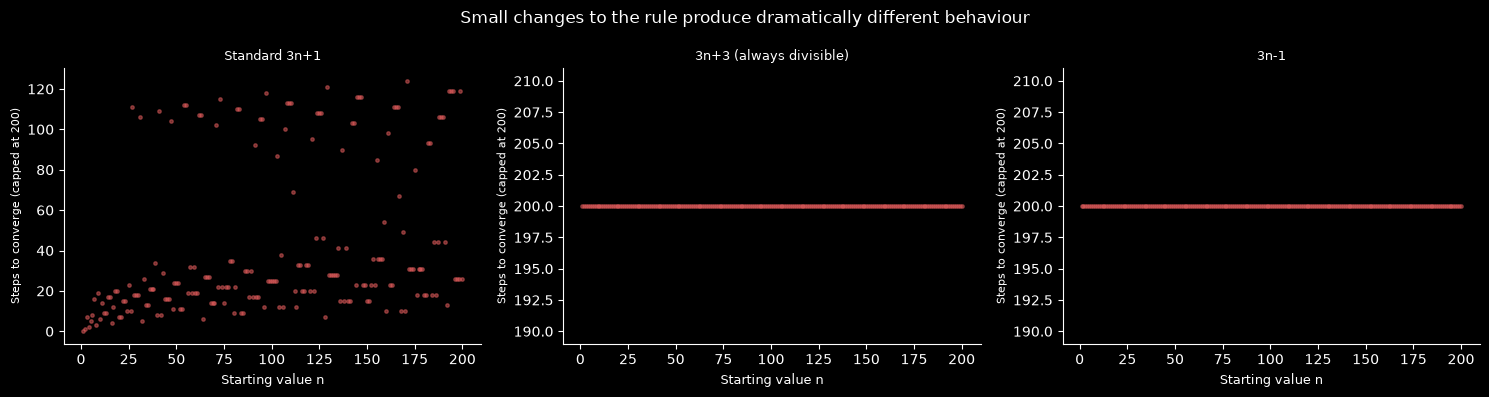

In [10]:
# Conway's generalisation - show that a slight generalisation
# produces provably unpredictable behaviour

# A Collatz-like function defined by residues mod m
# Conway showed these can simulate any Turing machine
# Here: illustrate how a small change in the rule produces wildly different behaviour

def generalised_collatz(n, rules, max_iter=500):
    """Apply a generalised Collatz rule defined as a dict {remainder: (multiply, add)}."""
    m = len(rules)
    seq = [n]
    for _ in range(max_iter):
        r = n % m
        a, b = rules[r]
        n = a * n + b
        if n == 1 or n <= 0:
            return seq
        seq.append(n)
        if len(seq) > max_iter:
            break
    return seq

# Standard Collatz: mod 2, even→n/2, odd→3n+1
# Expressed as: even: (1/2)n+0, odd: 3n+1
# We'll compare stopping time profiles for slight rule variations

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Small changes to the rule produce dramatically different behaviour', fontsize=12)

ns = range(1, 201)

configs = [
    ('Standard 3n+1', lambda n: stopping_time(n)),
    ('3n+3 (always divisible)', lambda n: len(generalised_collatz(n, {0:(1,0), 1:(3,3)})) ),
    ('3n-1', lambda n: len(generalised_collatz(n, {0:(1,0), 1:(3,-1)})) ),
]

for ax, (label, fn) in zip(axes, configs):
    try:
        sts = [min(fn(n), 200) for n in ns]
    except Exception:
        sts = [0] * len(list(ns))
    ax.scatter(list(ns), sts, s=6, alpha=0.5, color=ACCENT)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Starting value n', fontsize=9)
    ax.set_ylabel('Steps to converge (capped at 200)', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 5. The summary chart - four notebooks in one view

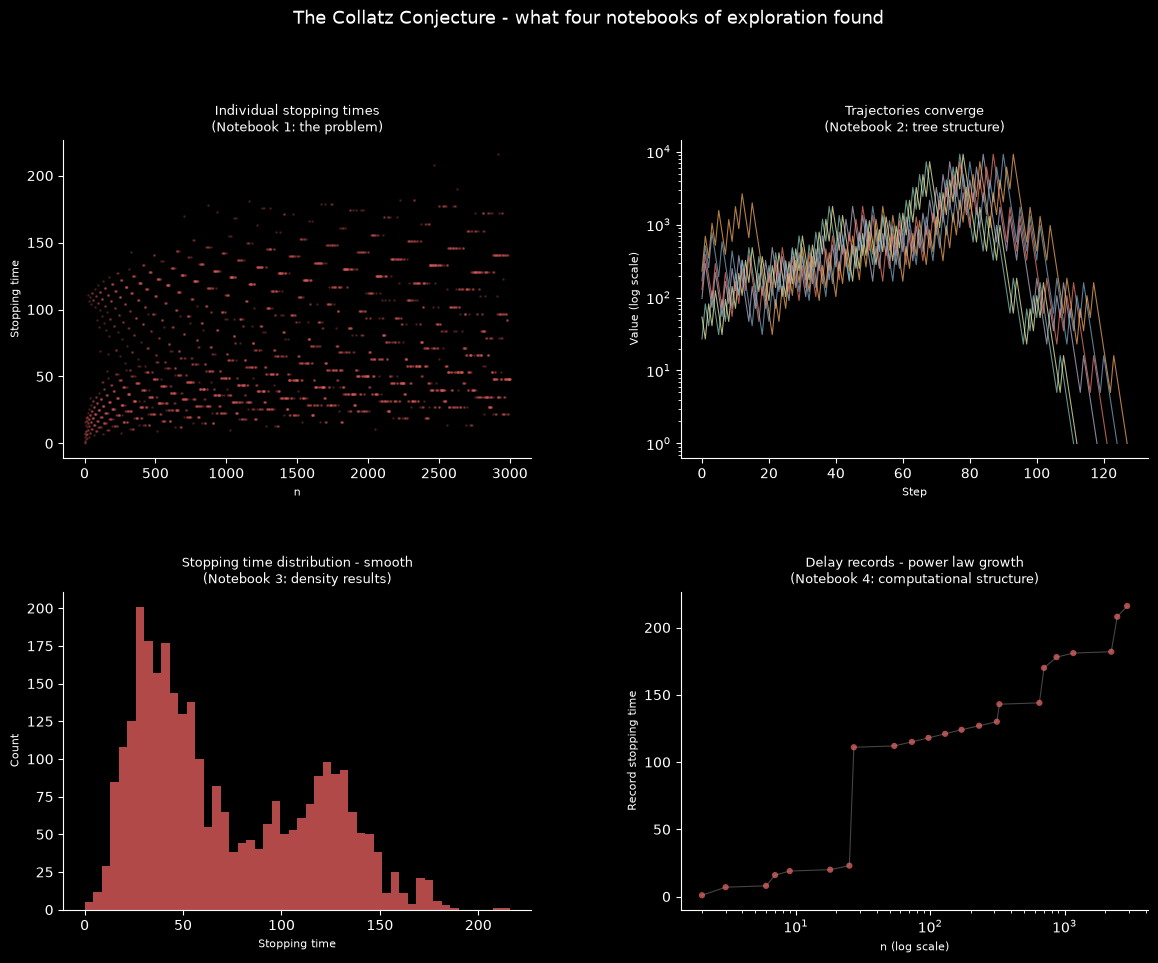

Saved: collatz_synthesis.png


In [11]:
# A four-panel summary of the key findings across all notebooks
fig = plt.figure(figsize=(14, 10))
fig.suptitle('The Collatz Conjecture - what four notebooks of exploration found',
             fontsize=13, y=1.01)
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.32)

N = 3000
ns_arr = np.arange(1, N+1)
sts_arr = np.array([stopping_time(n) for n in ns_arr])

# Panel 1: chaos in the individual (Notebook 1)
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(ns_arr, sts_arr, s=1, alpha=0.2, color=ACCENT)
ax1.set_title('Individual stopping times\n(Notebook 1: the problem)', fontsize=9)
ax1.set_xlabel('n', fontsize=8)
ax1.set_ylabel('Stopping time', fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Panel 2: tree structure / trajectory merging (Notebook 2)
ax2 = fig.add_subplot(gs[0, 1])
# Show how trajectories from different starts all pass through common values
for start in [27, 54, 97, 129, 171, 231]:
    seq = collatz_sequence(start)
    ax2.plot(range(len(seq)), seq, linewidth=0.8, alpha=0.7)
ax2.set_yscale('log')
ax2.set_title('Trajectories converge\n(Notebook 2: tree structure)', fontsize=9)
ax2.set_xlabel('Step', fontsize=8)
ax2.set_ylabel('Value (log scale)', fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel 3: distribution is orderly (Notebook 3 - density results)
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(sts_arr, bins=50, color=ACCENT, alpha=0.8, edgecolor='none')
ax3.set_title('Stopping time distribution - smooth\n(Notebook 3: density results)', fontsize=9)
ax3.set_xlabel('Stopping time', fontsize=8)
ax3.set_ylabel('Count', fontsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Panel 4: delay records (Notebook 4)
ax4 = fig.add_subplot(gs[1, 1])
records = []
current_max = 0
for n in range(1, N+1):
    st = stopping_time(n)
    if st > current_max:
        records.append((n, st))
        current_max = st

rec_ns, rec_sts = zip(*records)
ax4.scatter(rec_ns, rec_sts, s=20, color=ACCENT, alpha=0.8, edgecolor='none')
ax4.plot(rec_ns, rec_sts, color=NEUTRAL, linewidth=0.8, alpha=0.5)
ax4.set_xscale('log')
ax4.set_title('Delay records - power law growth\n(Notebook 4: computational structure)', fontsize=9)
ax4.set_xlabel('n (log scale)', fontsize=8)
ax4.set_ylabel('Record stopping time', fontsize=8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.savefig('collatz_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: collatz_synthesis.png')

## 6. Where I am at the end

I said in Notebook 1 that I wasn't trying to solve this. I'm not. But I think I understand it better than I did, and I can say something more precise about *why* it hasn't been solved.

The three walls I identified are real and they're not independent:

- **The density-universality gap** is a gap between what measure theory can see (typical behaviour) and what the conjecture requires (universal behaviour). Almost-all proofs and all-proofs are different kinds of mathematics.

- **Computational irreducibility** means that reasoning about individual trajectories requires running them. There's no shortcut from a property of $n$ to its stopping time. This makes any proof that reasons about individual cases impossible to shortcut.

- **The arithmetic of $3n+1$** sits in a neighbourhood of problems that are provably undecidable. Whether the specific Collatz Conjecture is undecidable is unknown, but the possibility is not dismissible.

These three walls are related: if the problem is computationally irreducible, that's evidence (not proof) of undecidability. If it's undecidable, the density-universality gap can never be closed, not because we lack the tools but because no tools could close it.

Erdős said mathematics is not yet ready for this problem. I think he was right, but possibly for the wrong reason. It's not that mathematics needs to mature - it may be that mathematics has fundamental limits, and the Collatz Conjecture sits close to them.

That's what a beautiful dead end looks like.

---

*This is the fifth and final notebook in the Collatz section of beautiful-dead-ends. The next problem in the series is to be determined - candidates include the Hadwiger Conjecture (graph colouring) and Kaprekar's constant (a more computationally tractable dead end with a different flavour of hardness).*